In [1]:
#Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Step 2: Load and prepare the Boston Housing dataset
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

# Combine the data properly
columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
           'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :3]])
boston_df = pd.DataFrame(data, columns=columns)

In [3]:
boston_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [4]:
#Step 3: Separate features and target variable
X = boston_df.drop('MEDV', axis=1)## independent features
y = boston_df['MEDV'] ## dependent features

In [5]:
from sklearn.linear_model import LinearRegression, Lasso

In [6]:
from sklearn.model_selection import cross_val_score, train_test_split

In [7]:
#Step 4: Implement Linear Regression with Cross-validation
regressor = LinearRegression()
mse = cross_val_score(regressor, X, y, scoring='neg_mean_squared_error', cv=5)

In [8]:
mse

array([-12.46030057, -26.04862111, -33.07413798, -80.76237112,
       -33.31360656])

In [15]:
mean_mse = np.mean(mse)
print("Linear Regression MSE:", -mean_mse)

Linear Regression MSE: 37.131807467699126


## Ridge Regression

In [23]:
from sklearn.linear_model import Ridge

In [25]:
from sklearn.model_selection import GridSearchCV

In [27]:
#Step 5: Implement Ridge Regression with GridSearchCV
ridge = Ridge()

In [29]:
parameters = {'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 1, 5, 10, 20, 30, 35, 40, 45, 50, 55, 100]}
ridge_regressor = GridSearchCV(ridge, parameters, scoring='neg_mean_squared_error', cv=5,verbose=1)
ridge_regressor.fit(X, y)

print("\nRidge Regression Results:")
print("Best parameters:", ridge_regressor.best_params_)
print("Best score:", -ridge_regressor.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Ridge Regression Results:
Best parameters: {'alpha': 100}
Best score: 29.905701947540308


In [31]:
# #Step 6: Implement Lasso Regression with GridSearchCV
# lasso = Lasso()
# lasso_params = {'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 1, 5, 10, 20, 30, 35, 40, 45, 50, 55, 100]}
# lasso_regressor = GridSearchCV(lasso, lasso_params, scoring='neg_mean_squared_error', cv=5)
# lasso_regressor.fit(X, y)

# print("\nLasso Regression Results:")
# print("Best parameters:", lasso_regressor.best_params_)
# print("Best score:", -lasso_regressor.best_score_)

In [33]:
#Step 6: Implement Lasso Regression with GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Initialize Lasso with increased max_iter to help with convergence
lasso = Lasso(max_iter=10000, tol=0.01)

# Define parameter grid
lasso_params = {
    'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 1, 5, 10, 20, 30, 35, 40, 45, 50, 55, 100]
}

# Perform GridSearchCV
lasso_regressor = GridSearchCV(
    lasso,
    lasso_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1  # Use all available cores
)

# Fit the model
lasso_regressor.fit(X, y)

# Print results
print("\nLasso Regression Results:")
print("Best parameters:", lasso_regressor.best_params_)
print("Best score:", -lasso_regressor.best_score_)

# Optional: Print all scores for different alphas
print("\nAll scores:")
means = lasso_regressor.cv_results_['mean_test_score']
stds = lasso_regressor.cv_results_['std_test_score']
for mean, std, params in zip(means, stds, lasso_regressor.cv_results_['params']):
    print("%0.3f (+/-%0.03f) for %r" % (-mean, std * 2, params))


Lasso Regression Results:
Best parameters: {'alpha': 1}
Best score: 35.61379536874345

All scores:
37.132 (+/-46.184) for {'alpha': 1e-15}
37.132 (+/-46.184) for {'alpha': 1e-10}
37.132 (+/-46.184) for {'alpha': 1e-08}
37.026 (+/-46.247) for {'alpha': 0.001}
36.200 (+/-46.777) for {'alpha': 0.01}
35.614 (+/-34.246) for {'alpha': 1}
43.099 (+/-40.650) for {'alpha': 5}
46.467 (+/-45.977) for {'alpha': 10}
56.322 (+/-54.200) for {'alpha': 20}
69.572 (+/-62.483) for {'alpha': 30}
71.581 (+/-60.776) for {'alpha': 35}
72.032 (+/-60.864) for {'alpha': 40}
72.429 (+/-60.672) for {'alpha': 45}
72.643 (+/-60.674) for {'alpha': 50}
72.804 (+/-60.693) for {'alpha': 55}
73.867 (+/-60.910) for {'alpha': 100}


In [34]:
#Step 7: Split data for prediction comparison
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [35]:
#Step 8: Get predictions
prediction_ridge = ridge_regressor.predict(X_test)
prediction_lasso = lasso_regressor.predict(X_test)

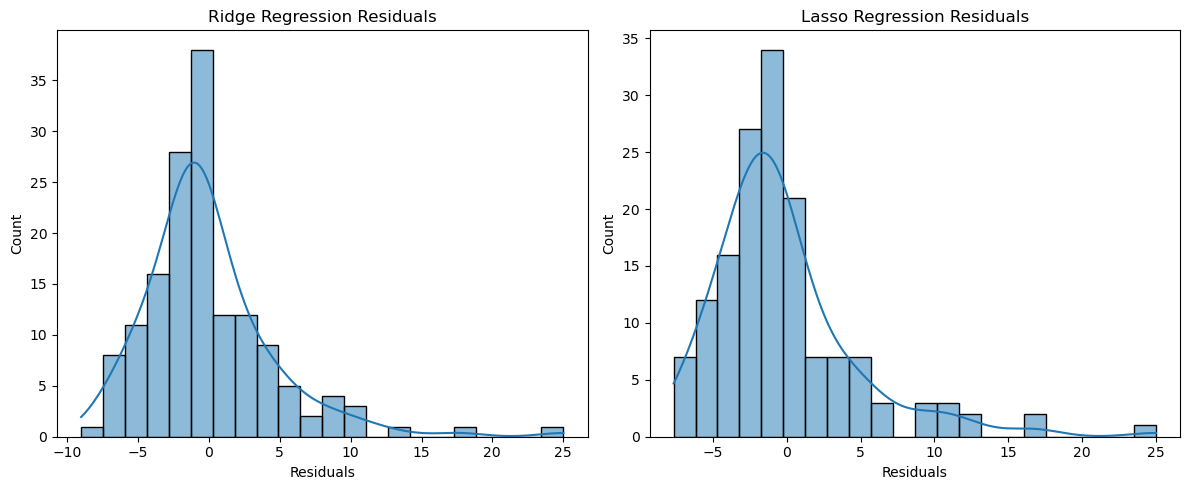

In [36]:
#Step 9: Visualize residuals
plt.figure(figsize=(12, 5))
# Ridge regression residuals
plt.subplot(1, 2, 1)
sns.histplot(y_test - prediction_ridge, kde=True)
plt.title('Ridge Regression Residuals')
plt.xlabel('Residuals')

# Lasso regression residuals
plt.subplot(1, 2, 2)
sns.histplot(y_test - prediction_lasso, kde=True)
plt.title('Lasso Regression Residuals')
plt.xlabel('Residuals')

plt.tight_layout()
plt.show()

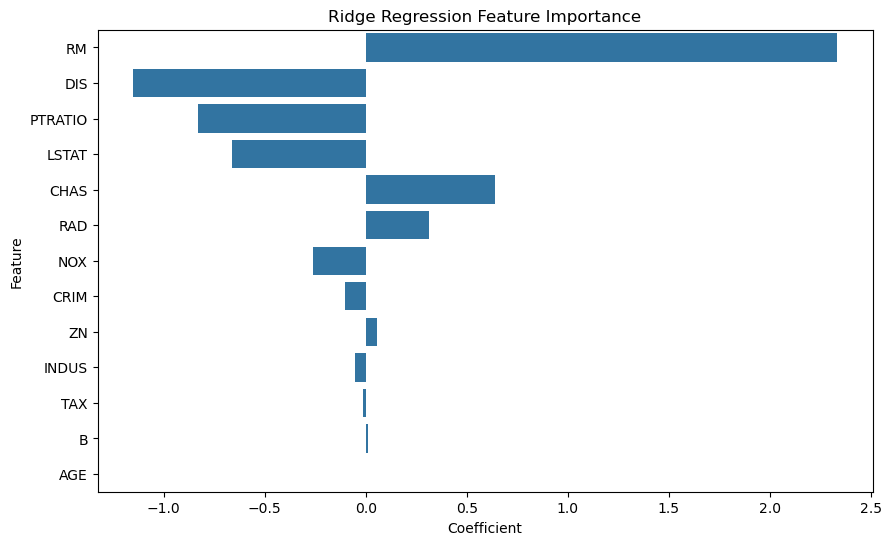

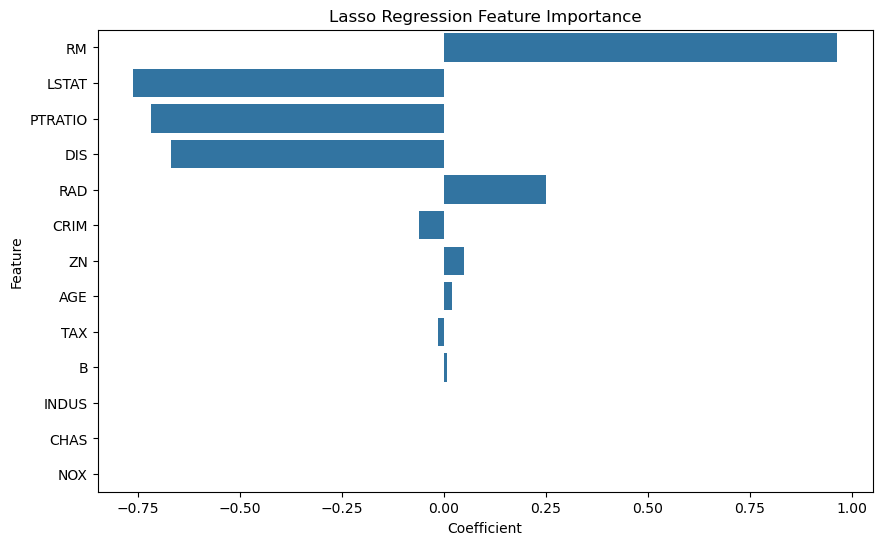

In [37]:
#Step 10: Feature importance visualization
# Ridge regression feature importance
ridge_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge_regressor.best_estimator_.coef_
})
ridge_importance = ridge_importance.sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=ridge_importance)
plt.title('Ridge Regression Feature Importance')
plt.show()

# Lasso regression feature importance
lasso_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_regressor.best_estimator_.coef_
})
lasso_importance = lasso_importance.sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=lasso_importance)
plt.title('Lasso Regression Feature Importance')
plt.show()

In [38]:
#Step 11: Print model performance metrics
from sklearn.metrics import mean_squared_error, r2_score

print("\nModel Performance Metrics:")
print("\nRidge Regression:")
print("MSE:", mean_squared_error(y_test, prediction_ridge))
print("R2 Score:", r2_score(y_test, prediction_ridge))

print("\nLasso Regression:")
print("MSE:", mean_squared_error(y_test, prediction_lasso))
print("R2 Score:", r2_score(y_test, prediction_lasso))


Model Performance Metrics:

Ridge Regression:
MSE: 21.406073011870916
R2 Score: 0.7127206587146266

Lasso Regression:
MSE: 24.01450032002871
R2 Score: 0.6777143650117698
